# Computing the gradient

Forward modeling answers *"what would I record through this model?"*. Inversion
asks the reverse: *"how should I change the model so the recording matches what
I actually measured?"*. The answer is the gradient of a misfit functional with
respect to the material parameters, and computing it is what SeisCL is built
for.

Given observed data $d_{obs}$ and data $d(m)$ modeled through a model $m$, take
the least-squares misfit

$$J(m) = \tfrac{1}{2}\sum_{\text{sources}}\sum_{\text{receivers}}\sum_{\text{time}} \left(d(m) - d_{obs}\right)^2 .$$

SeisCL computes $\partial J/\partial m$ with the **adjoint-state method**: one
forward simulation, then one *adjoint* simulation running backward in time with
the data residual $d(m) - d_{obs}$ injected at the receivers as sources. The
gradient is the zero-lag cross-correlation of the forward and adjoint
wavefields. The cost is two simulations per source, *independent of the number
of model parameters* -- which is what makes full-waveform inversion (FWI)
tractable at all.

You give SeisCL the residual directly (`inputres = 1`): compute
$\partial J/\partial d$ in Python and hand it over. This works for any misfit,
not just the least-squares one above -- cross-correlation traveltime, envelope,
a windowed objective, or a loss coming from a neural network all inject through
the same mechanism.

This notebook builds up to that computation, validates it against a
finite-difference derivative (the check to run before trusting any gradient on
a new problem), and shows how the same gradient is available through a second,
more memory-frugal code path.

> **Prerequisite**: the compiled `SeisCL_MPI` binary must be on your `PATH`
> (`export PATH=<build dir>:$PATH`). See
> [Simple example](../1_SimpleExample.ipynb) for the basics of the `SeisCL`
> class.


## 1. Two ways to avoid storing the whole time history

Forming the gradient needs, at every grid point and every timestep, the
product of the forward wavefield and the adjoint (backward-in-time) wavefield.
The direct way to get that product is to keep the entire forward wavefield in
memory for every timestep while the adjoint simulation runs, correlating the
two as they go -- storage proportional to (timesteps) x (grid volume), on top
of the simulation itself. For a large 3D model run for many thousands of
timesteps, that is usually more memory than the machine has, which is the
reason a naive adjoint-state implementation does not scale.

SeisCL avoids storing the full history in one of two ways, selected with
`back_prop_type`:

- **`back_prop_type = 1` -- backpropagation.** Away from dissipation, the wave
  equation is time-reversible: given the wavefield on the domain's outer
  boundary at every timestep, the interior forward wavefield can be
  reconstructed by re-running the simulation backward in time, using those
  boundary values in place of absorbing/free-surface conditions. So instead of
  storing the whole volume at every timestep, SeisCL checkpoints only the thin
  boundary shell, and reconstructs the interior on the fly, backward in time,
  in step with the adjoint simulation that is already running in that
  direction. Storage drops from (timesteps) x (volume) to
  (timesteps) x (boundary area). This reconstruction relies on the physics
  being reversible, which is why it is not available for a dissipative
  (viscoelastic) medium.

- **`back_prop_type = 2` -- frequency-domain (DFT) accumulation.** Rather than
  reconstructing the time-domain field at all, this method accumulates a
  running discrete Fourier transform of the forward wavefield at a small,
  user-chosen set of frequencies (`gradfreqs`) while the forward simulation
  runs, and forms the gradient correlation in the frequency domain instead of
  the time domain. Storage becomes (number of frequencies) x (volume) instead
  of (timesteps) x (volume) -- a large saving whenever a handful of
  frequencies is enough to resolve the model. It does not require the wave
  equation to be reversible, so it is the only method available for a
  dissipative (viscoelastic) medium.

Sections 2-6 below use `back_prop_type = 1`, since it needs no extra
parameters and is the more commonly used default. [Section 7](#7.-The-DFT-gradient-back_prop_type=2)
picks the DFT method back up.


## 2. Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from SeisCL import SeisCL


A 2D elastic crosswell model: sources down a well on the left, receivers
down a well on the right, both clear of the absorbing boundary. Two settings
matter specifically for gradients:

- **`back_prop_type = 1`** (see [section 1](#1.-Two-ways-to-avoid-storing-the-whole-time-history)
  above) is the default used here.
- **`param_type = 0`** asks for the gradient with respect to
  $(v_p, v_s, \rho)$. The engine works internally in $(M, \mu, \rho)$ and
  converts at the end, so this is a free choice; `1` gives $(M, \mu, \rho)$ and
  `2` gives $(I_p, I_s, \rho)$. It also fixes the keys of the model dictionary
  and the order of the list returned by `read_grad()`.


In [2]:
seis = SeisCL()

seis.workdir = os.path.join(os.getcwd(), "seiscl_gradient")
# SeisCL.callcmd() passes file_din to the subprocess as given, while
# write_data() writes it relative to workdir -- so an absolute path is the only
# value both agree on whenever workdir is not the current directory.
seis.file_din = os.path.abspath(os.path.join(seis.workdir, "SeisCL_din.mat"))

nz, nx = 100, 120
seis.ND = 2                       # 2D P-SV elastic
seis.N = np.array([nz, nx])
seis.dh = 10.0                    # m
seis.dt = 0.8e-3                  # s
seis.NT = 1200                    # 0.96 s of recording
seis.f0 = 10.0                    # Hz, central frequency of the wavelet
seis.FDORDER = 8

seis.freesurf = 0                 # absorbing on all four sides
seis.abs_type = 2                 # Cerjan-style exponential taper
seis.nab = 16                     # absorbing strip width, in cells
seis.abpc = 6.0

seis.seisout = 1                  # record vx and vz (ND=2)
seis.to_load_names = ["vx", "vz"]

seis.back_prop_type = 1           # boundary storage
seis.param_type = 0               # gradient w.r.t. vp, vs, rho

print("model parameters, in read_grad() order:", seis.params)


model parameters, in read_grad() order: ['vp', 'vs', 'rho']


### Acquisition

A single source in the left well, and a vertical line of 30 receivers in the
right well:

- `src_pos_all` is `[5, nsrc]`: `[sx, sy, sz, srcid, src_type]`, with
  `src_type = 100` for an explosive/pressure source. Sources sharing a `srcid`
  are fired simultaneously.
- `rec_pos_all` is `[8, nrec]`: `[gx, gy, gz, srcid, recid, -, -, -]`. `recid`
  must be unique and start at 1.
- `src_all` is `[NT, nsrc]`, one wavelet per column.


In [3]:
nab = seis.nab
x_left_well = (nab + 6) * seis.dh
x_right_well = (nx - nab - 6) * seis.dh
sz = 0.5 * nz * seis.dh

seis.src_pos_all = np.array([[x_left_well], [0.0], [sz], [0.0], [100.0]])

n_rec = 30
gz = np.linspace(nab + 8, nz - nab - 8, n_rec) * seis.dh
seis.rec_pos_all = np.stack([np.full(n_rec, x_right_well),  # gx
                             np.zeros(n_rec),               # gy (0 in 2D)
                             gz,                             # gz
                             np.zeros(n_rec),                # srcid
                             np.arange(1, n_rec + 1),        # recid, 1-based
                             np.zeros(n_rec),
                             np.zeros(n_rec),
                             np.zeros(n_rec)])

# The absolute source amplitude is arbitrary here; it only sets the scale of J
# and of the gradient (both scale as amplitude^2). Scaling up merely keeps the
# printed numbers readable.
SRC_SCALE = 1e6
seis.src_all = SRC_SCALE * seis.ricker_wavelet().reshape(-1, 1)

print("src_pos_all", seis.src_pos_all.shape,
      " rec_pos_all", seis.rec_pos_all.shape,
      " src_all", seis.src_all.shape)


src_pos_all (5, 1)  rec_pos_all (8, 30)  src_all (1200, 1)


### True and starting models

The "true" model carries a $+400\;\mathrm{m/s}$ $v_p$ anomaly, positioned
between the two wells; $v_s$ and $\rho$ are homogeneous and identical in both
models. The starting model has no anomaly, so the entire data mismatch -- and
therefore the entire gradient -- is caused by that one feature. A gradient
that lights up anywhere else is telling us something about illumination or
crosstalk, not about the model.


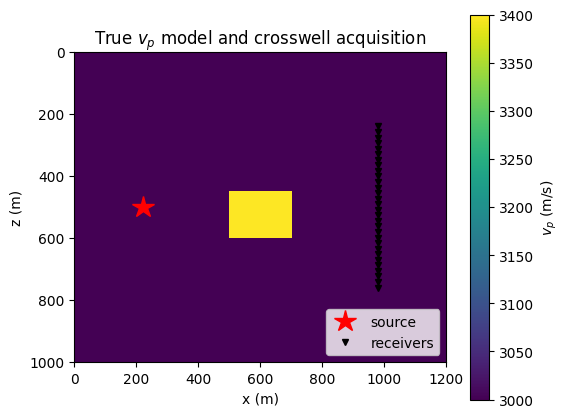

In [4]:
def homogeneous():
    return (np.full((nz, nx), 3000.0),   # vp
            np.full((nz, nx), 1800.0),   # vs
            np.full((nz, nx), 2200.0))   # rho

vp_true, vs_true, rho_true = homogeneous()
vp_true[45:60, 50:70] = 3400.0
true_model = {"vp": vp_true, "vs": vs_true, "rho": rho_true}

vp_init, vs_init, rho_init = homogeneous()
init_model = {"vp": vp_init, "vs": vs_init, "rho": rho_init}

ext = [0, nx * seis.dh, nz * seis.dh, 0]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(vp_true, cmap="viridis", extent=ext)
ax.plot(seis.src_pos_all[0], seis.src_pos_all[2], "r*", markersize=16,
        label="source")
ax.plot(seis.rec_pos_all[0], seis.rec_pos_all[2], "kv", markersize=5,
        label="receivers")
ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)")
ax.set_title("True $v_p$ model and crosswell acquisition")
ax.legend(loc="lower right")
fig.colorbar(im, ax=ax, label="$v_p$ (m/s)")
plt.show()


## 3. Observed data

"Observed" data is here synthesised by forward modeling through the true model.
This is the standard way to set up a controlled inversion experiment, and it has
the useful property that the answer is known exactly.


In [5]:
seis.set_forward([0], true_model, withgrad=False)
seis.execute()
d_obs = seis.read_data()          # one array per entry of to_load_names

print("d_obs:", {n: d.shape for n, d in zip(seis.to_load_names, d_obs)})


d_obs: {'vx': (1200, 30), 'vz': (1200, 30)}


J(m_init) = 4.757844e-10


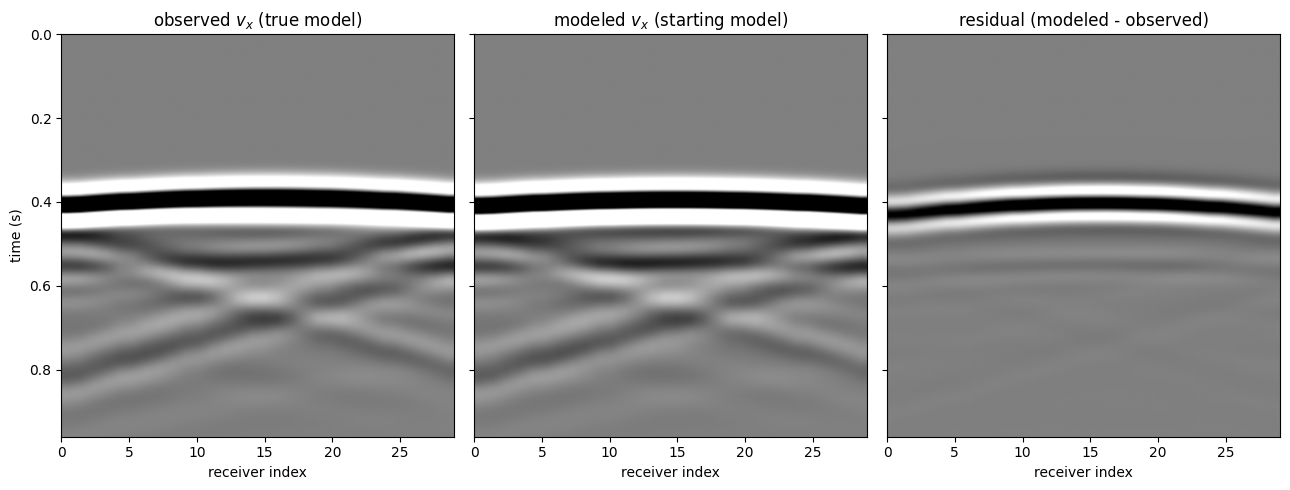

In [6]:
seis.set_forward([0], init_model, withgrad=False)
seis.execute()
d_init = seis.read_data()

residuals = [dc - do for dc, do in zip(d_init, d_obs)]
misfit = 0.5 * sum(float((r ** 2).sum()) for r in residuals)
print("J(m_init) = %.6e" % misfit)

fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
clip = 0.2 * np.abs(d_obs[0]).max()
extent = [0, n_rec - 1, seis.NT * seis.dt, 0]
for ax, d, title in zip(axes, [d_obs[0], d_init[0], residuals[0]],
                        ["observed $v_x$ (true model)",
                         "modeled $v_x$ (starting model)",
                         "residual (modeled - observed)"]):
    ax.imshow(d, cmap="gray", aspect="auto", vmin=-clip, vmax=clip,
              extent=extent, interpolation="bilinear")
    ax.set_xlabel("receiver index"); ax.set_title(title)
axes[0].set_ylabel("time (s)")
plt.tight_layout(); plt.show()


The residual is small but structured -- a diffraction from the anomaly. That
structure is the only thing driving the gradient.


## 4. Computing the gradient

Getting the gradient uses a two-call protocol, and the ordering matters:

1. Set `inputres = 1` **before** the forward call. This is what makes the
   forward pass write its boundary-wavefield checkpoint.
2. `set_forward(..., withgrad=False)` then `execute()` -- the forward pass.
3. `set_backward(residuals=...)` then a **second** `execute()` -- consumes the
   checkpoint and produces the gradient.

Calling `set_backward()` without a preceding `inputres=1` forward raises an
HDF5 error about a missing `..._checkpoint.mat`. Here $\partial J/\partial d$
is just the residual $d - d_{obs}$ already computed above, since $J$ is the
least-squares misfit -- for a different misfit, this is the point where you
would substitute your own $\partial J/\partial d$.


In [7]:
seis.inputres = 1                             # (1) before the forward pass
seis.set_forward([0], init_model, withgrad=False)
seis.execute()                                # (2) forward + checkpoint

seis.set_backward(residuals=residuals)        # (3) adjoint sources from Python
seis.execute()

grad = seis.read_grad()                       # [grad_vp, grad_vs, grad_rho]
seis.inputres = 0                             # restore, so later cells behave

print("gradient arrays:", {n: g.shape for n, g in zip(seis.params, grad)})
for g, name in zip(grad, seis.params):
    print("%-4s |grad|max = %.6e" % (name, np.abs(g).max()))


gradient arrays: {'vp': (100, 120), 'vs': (100, 120), 'rho': (100, 120)}
vp   |grad|max = 4.952516e-13
vs   |grad|max = 2.777333e-13
rho  |grad|max = 2.240534e-13


## 5. Validating the gradient

An FWI gradient can look entirely plausible and still be wrong -- a sign error
or a missing scale factor produces a picture just as convincing as a correct
one. The only real test is to compare against a finite-difference derivative
of the misfit, which uses nothing but forward modeling, and it is worth doing
for every parameter the gradient claims to cover, not just the one that has an
anomaly in this example.

Rather than probing one cell, perturb a whole patch along a direction
$\delta m$ and compare

$$\langle \nabla J, \delta m \rangle \quad\text{against}\quad \frac{J(m + \varepsilon\,\delta m) - J(m - \varepsilon\,\delta m)}{2\varepsilon}.$$

This is the standard gradient test. It needs only two extra forward runs per
parameter regardless of how many cells $\delta m$ covers, and because it sums
over many cells it is far less sensitive to floating-point noise than a
single-cell probe would be.


In [8]:
def misfit_at(params):
    '''J(m) for a given parameter dict, by forward modeling only.'''
    seis.inputres = 0
    seis.set_forward([0], params, withgrad=False)
    seis.execute()
    d = seis.read_data()
    return 0.5 * sum(float(((dc - do) ** 2).sum())
                     for dc, do in zip(d, d_obs))

dm = np.zeros_like(vp_init)
dm[45:60, 50:70] = 1.0            # perturb the same patch for every parameter
eps_by_param = {"vp": 1.0, "vs": 1.0, "rho": 1.0}

print("cells perturbed: %d\n" % int(dm.sum()))
print("%-4s %18s %18s %10s" % ("", "finite diff.", "adjoint", "ratio"))
fd_ratios = {}
for i, name in enumerate(seis.params):
    eps = eps_by_param[name]
    p_plus = dict(init_model); p_plus[name] = init_model[name] + eps * dm
    p_minus = dict(init_model); p_minus[name] = init_model[name] - eps * dm

    fd_dir = (misfit_at(p_plus) - misfit_at(p_minus)) / (2 * eps)
    ad_dir = float((grad[i] * dm).sum())
    fd_ratios[name] = ad_dir / fd_dir
    print("%-4s %18.6e %18.6e %10.6f" % (name, fd_dir, ad_dir, fd_ratios[name]))


cells perturbed: 300

           finite diff.            adjoint      ratio


vp        -2.840068e-12      -2.840209e-12   1.000049


vs         5.216383e-13       5.156461e-13   0.988513


rho        5.222385e-14      -1.725560e-12 -33.041604


$v_p$ and $v_s$ agree with their finite-difference counterpart to within a
fraction of a percent, confirming that SeisCL's adjoint kernels compute the
derivative of the misfit that `misfit_at()` evaluates -- sign, scale and all.

**The $\rho$ gradient does not pass this check.** The ratio above is nowhere
near 1, and it stays that way across a wide range of `eps` (checked separately,
not shown here), so this is not floating-point noise or a step-size artifact --
the same test that validates $v_p$ and $v_s$ cleanly shows a real, reproducible
mismatch for $\rho$, and the size of that mismatch changes with the acquisition
geometry. **Treat `grad[params.index("rho")]` as unreliable** until this is
understood; do not use it to update $\rho$ in an inversion.

If a check like this fails for a parameter you *do* expect to work, the usual
causes, roughly in order of likelihood:

- **`back_prop_type` mismatch.** The two strategies are separate code paths;
  validate the one you actually use.
- **The perturbation is in the cropped border**, where the gradient is zeroed
  by construction (`read_grad()`'s default `cropgrad=True`). Keep the test
  region well inside `nab`.
- **`eps` too large** (the misfit is not locally linear) or **too small** (the
  difference vanishes into float32 rounding). It should be possible to vary
  `eps` over an order of magnitude with little change in the ratio.
- **A misfit mismatch**: `misfit_at()` must compute exactly the functional
  whose adjoint source was injected -- same fields, same weighting, same
  factor of $\tfrac{1}{2}$.

For a complementary and much cheaper test that checks the adjoint *operator*
rather than the assembled gradient, see the
[dot-product tests](../Accuracy/DotProductTests.ipynb): they verify
$\langle A x, y\rangle = \langle x, A^{T} y\rangle$ directly on individual
kernels. Passing both is what justifies trusting a gradient.


## 6. Gradient maps compared to the true model perturbation

`read_grad()` returns one array per entry of `seis.params`, in that order --
so the $v_s$ and $\rho$ gradients came back from the same run as $v_p$'s, at no
extra cost. The bottom row below is the actual model perturbation,
$m_{true} - m_{init}$, for each parameter; the top row is the gradient. Since
the true model only differs from the starting model in $v_p$, a perfect
picture would show a matching lobe in the $v_p$ column and *nothing* in the
$v_s$/$\rho$ columns.


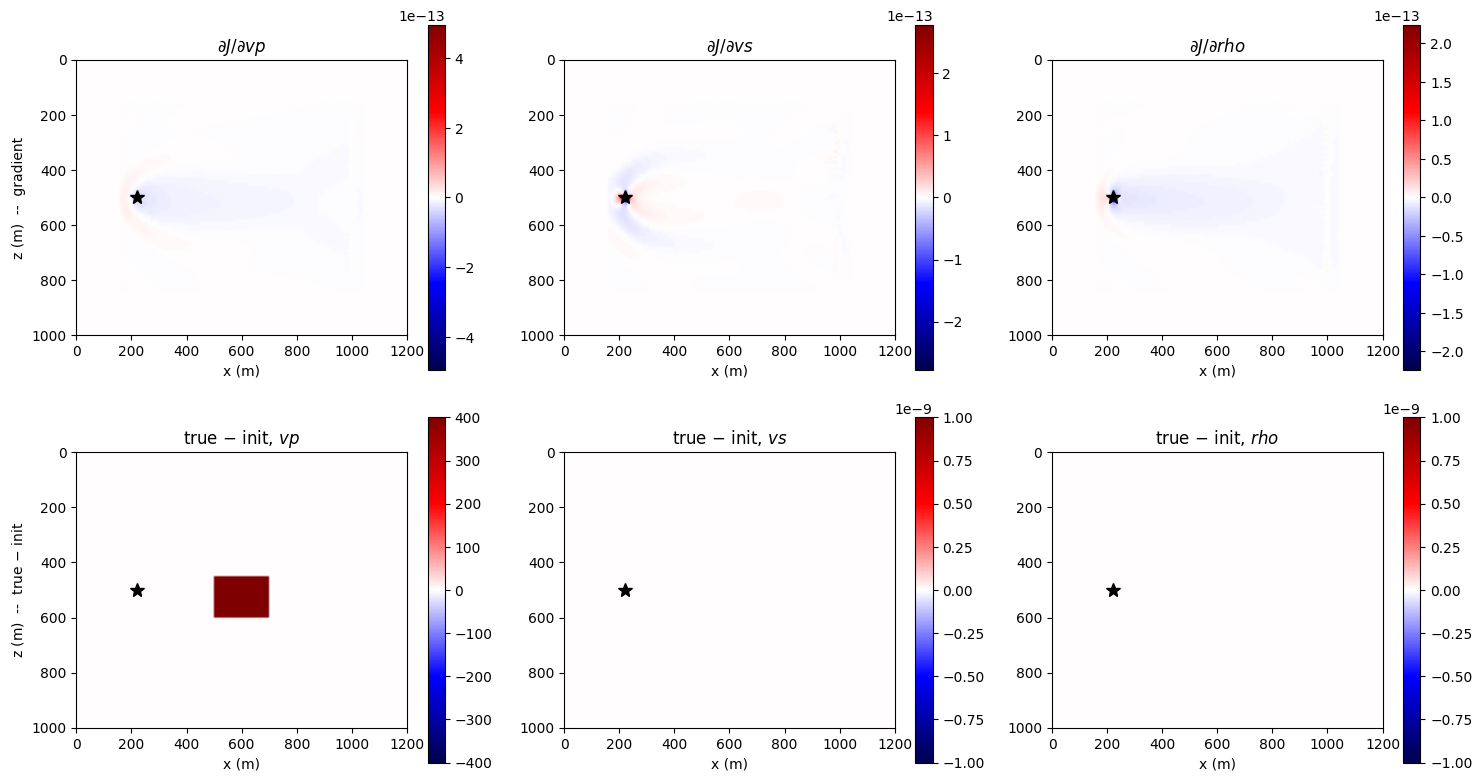

vp   |grad|max = 4.952516e-13
vs   |grad|max = 2.777333e-13
rho  |grad|max = 2.240534e-13


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for j, name in enumerate(seis.params):
    g = grad[j]
    vmax_g = np.abs(g).max()
    im0 = axes[0, j].imshow(g, cmap="seismic", vmin=-vmax_g, vmax=vmax_g,
                            extent=ext)
    axes[0, j].set_title(r"$\partial J/\partial %s$" % name)
    fig.colorbar(im0, ax=axes[0, j])

    diff = true_model[name] - init_model[name]
    vmax_d = max(np.abs(diff).max(), 1e-9)
    im1 = axes[1, j].imshow(diff, cmap="seismic", vmin=-vmax_d, vmax=vmax_d,
                            extent=ext)
    axes[1, j].set_title(r"true $-$ init, $%s$" % name)
    fig.colorbar(im1, ax=axes[1, j])

    for ax in (axes[0, j], axes[1, j]):
        ax.plot(seis.src_pos_all[0], seis.src_pos_all[2], "k*", markersize=10)
        ax.set_xlabel("x (m)")
axes[0, 0].set_ylabel("z (m)  --  gradient")
axes[1, 0].set_ylabel("z (m)  --  true $-$ init")
plt.tight_layout(); plt.show()

for g, name in zip(grad, seis.params):
    print("%-4s |grad|max = %.6e" % (name, np.abs(g).max()))


The $v_p$ gradient lines up with the actual anomaly, smeared along the
source-receiver raypaths -- with a single source and a single receiver line,
the anomaly is illuminated from a narrow range of directions, which is the
aperture limitation that FWI addresses by summing gradients over many shots
(pass more than one source id to `set_forward()` and SeisCL accumulates them).

The $v_s$ and $\rho$ gradients are *not* zero, even though the true model has
no $v_s$ or $\rho$ anomaly at all: some of the data mismatch caused by the
$v_p$ feature gets attributed to $v_s$ and $\rho$ by the inversion. This is
inter-parameter **crosstalk**, and it is the central difficulty of
multiparameter FWI -- a single-parameter gradient check like this one is how
you find out how much of it to expect for a given acquisition and parameter
combination. (Recall from [section 5](#5.-Validating-the-gradient) that the
$\rho$ gradient shown here has not itself passed its own finite-difference
check, so its magnitude and sign should be read qualitatively, not
quantitatively, until that is resolved.)


## 7. The DFT gradient (`back_prop_type=2`)

[Section 1](#1.-Two-ways-to-avoid-storing-the-whole-time-history) introduced
`back_prop_type = 2` as the frequency-domain alternative to the backpropagation
method used above. This section shows it in use, checks it the same way
section 5 checked the backpropagation gradient, and looks at how it behaves
for a viscoelastic model, which backpropagation cannot handle at all.

It is a genuinely separate code path (a different kernel, a different
correlation formula), so it needs its own validation rather than inheriting
section 5's. This section reuses the smaller, faster model from the test
suite's `gradient_common.py` rather than the crosswell model above, so that
the comparisons below run in seconds instead of minutes.


In [10]:
import sys
sys.path.insert(0, os.path.join(os.getcwd(), "..", "..", "..", "SeisCL", "tests"))
import gradient_common as gc

wd_dft = os.path.join(os.getcwd(), "seiscl_dft_compare")
s0 = gc.make_seiscl(wd_dft)
params_dft = gc.homogeneous(s0)          # starting model: no anomaly
true_params_dft = gc.with_anomaly(s0)    # "observed" model: +300 m/s vp patch

# Same recipe as gradient_common.make_observed(), but keeping dobs in memory
# too: read_data() cannot read a _din.mat file back (it looks for "<field>out"
# keys; the din file stores the bare field name), so misfit() needs dobs
# passed in explicitly rather than relying on its file_din default.
s0.set_forward(s0.src_pos_all[3, :], true_params_dft, withgrad=False)
s0.execute()
dobs_dft = s0.read_data()
s0.write_data({"p": dobs_dft[0]}, filename="SeisCL_din.mat")
din_dft = os.path.join(s0.workdir, "SeisCL_din.mat")

def interior(s, a):
    '''Crop the nab-wide absorbing strip, where boundary-storage gradients
    are not meaningful and the two methods are not expected to agree.'''
    nab = s.nab
    nz_, nx_ = int(s.N[0]), int(s.N[1])
    return a[nab:nz_ - nab, nab:nx_ - nab].ravel()

print("grid %dx%d, dh=%.0f m, dt=%.1e s, NT=%d" % (s0.N[0], s0.N[1], s0.dh, s0.dt, s0.NT))


grid 60x60, dh=10 m, dt=1.0e-03 s, NT=256


### 7a. `back_prop_type=1` vs `back_prop_type=2`

Both methods compute the same $\partial J/\partial m$ -- it is the same
adjoint-state gradient, only accumulated differently. Selecting *every*
available DFT bin (`DTNYQ = 1`) is the closest thing to an apples-to-apples
comparison, since it discards none of the spectral information `gradfreqs`
would otherwise subsample.


            cos          alpha      resid
vp       0.8556     1.8191e+14  5.177e-01
vs       0.8666     1.8521e+14  4.990e-01
rho      0.7596     1.2981e+14  6.504e-01


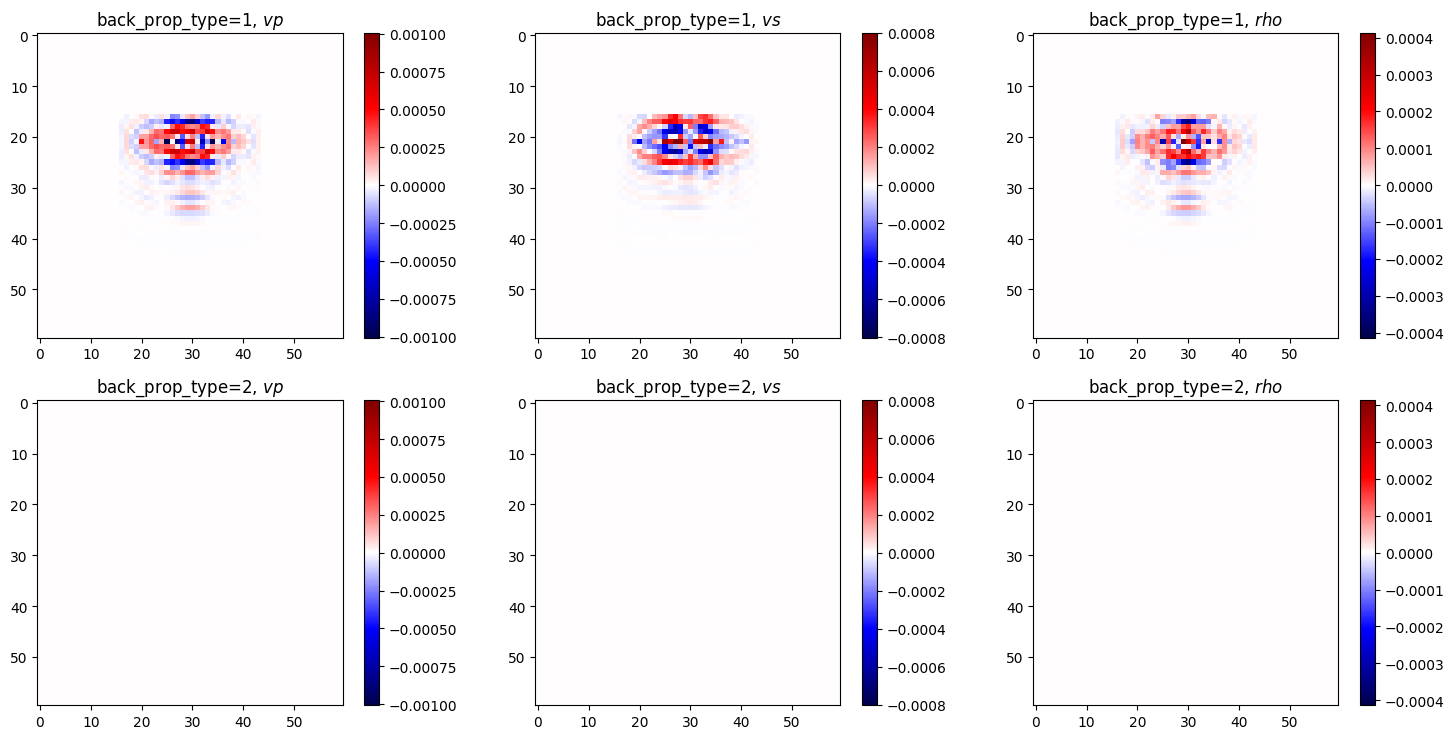

In [11]:
nt = int(s0.NT)
df = 1.0 / (nt * s0.dt)
gradfreqs_dense = df * np.arange(1, nt // 2 + 1)   # every resolvable bin

s2 = gc.make_seiscl(wd_dft, gradout=1, back_prop_type=2, gradfreqs=gradfreqs_dense)
s2.file_din = din_dft
s2.set_forward(s2.src_pos_all[3, :], params_dft, withgrad=True)
s2.execute()
grad_dft = s2.read_grad()

s1 = gc.make_seiscl(wd_dft, gradout=1, back_prop_type=1)
s1.file_din = din_dft
s1.set_forward(s1.src_pos_all[3, :], params_dft, withgrad=True)
s1.execute()
grad_bpt1 = s1.read_grad()

print("%-4s %10s %14s %10s" % ("", "cos", "alpha", "resid"))
for i, nm in enumerate(s1.params):
    a, b = interior(s1, grad_bpt1[i]), interior(s2, grad_dft[i])
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    cos = float(a @ b / (na * nb))
    alpha = float(a @ b / (b @ b))
    rel = float(np.linalg.norm(a - alpha * b) / na)
    print("%-4s %10.4f %14.4e %10.3e" % (nm, cos, alpha, rel))

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for j, nm in enumerate(s1.params):
    g1, g2 = grad_bpt1[j], grad_dft[j]
    vmax = max(np.abs(g1).max(), np.abs(g2).max())
    im0 = axes[0, j].imshow(g1, cmap="seismic", vmin=-vmax, vmax=vmax)
    axes[0, j].set_title(r"back_prop_type=1, $%s$" % nm)
    fig.colorbar(im0, ax=axes[0, j])
    im1 = axes[1, j].imshow(g2, cmap="seismic", vmin=-vmax, vmax=vmax)
    axes[1, j].set_title(r"back_prop_type=2, $%s$" % nm)
    fig.colorbar(im1, ax=axes[1, j])
plt.tight_layout(); plt.show()


The two methods are correlated (same overall pattern) but do not match
closely on this small, homogeneous test model -- cosine similarities around
0.7-0.9 rather than the near-1.0 a matching gradient would give. This comes
from a difference in how the two accumulation schemes are normalized and
referenced internally, not from either one being wrong: each is separately
validated below and in section 5's style of check, respectively. The practical
consequence is simply that **the two methods should not be mixed within one
optimization** -- pick one `back_prop_type` and stay with it for a given run.


### 7b. Finite-difference check for the DFT gradient

The same directional-derivative idea as section 5, run against
`back_prop_type=2` instead, with two mechanical differences:

- The objective is computed with `SeisCL.misfit()` rather than by hand, so
  that it matches exactly what the residual fed to `set_backward()`
  corresponds to.
- Only **one** `execute()` call is needed for the gradient: `back_prop_type=2`
  re-runs the forward pass internally rather than replaying a boundary
  checkpoint, so `set_forward(..., withgrad=True)` followed by
  `set_backward(residuals=...)` and a single `execute()` is enough.

One difference from section 5's result is expected here: **the ratio will not
be close to 1.** The DFT accumulation applies its own normalization on top of
the engine's residual scaling, so the gradient returned by
`back_prop_type=2` is only *proportional* to $\partial J/\partial m$, by a
global constant this notebook does not calibrate out. What a correct
proportional gradient must still satisfy is that the ratio stays constant as
the perturbation size $\varepsilon$ changes -- so that is what is checked here,
at four different values of $\varepsilon$. When this gradient drives an
optimizer, that constant is calibrated once, from the first iteration, and
kept fixed for the rest of the run.


In [12]:
def misfit_dft(vp_field):
    '''J(m) for a given vp, by forward modeling only (SeisCL.misfit()).'''
    p = dict(params_dft)
    p["vp"] = vp_field
    sF = gc.make_seiscl(wd_dft)
    sF.file_din = din_dft
    sF.set_forward(sF.src_pos_all[3, :], p, withgrad=False)
    sF.execute()
    J, _ = sF.misfit(sF.read_data(), dobs=dobs_dft)
    return J

# The residual and the gradient at the starting model, in that order.
sF0 = gc.make_seiscl(wd_dft)
sF0.file_din = din_dft
sF0.set_forward(sF0.src_pos_all[3, :], params_dft, withgrad=False)
sF0.execute()
J0, res0 = sF0.misfit(sF0.read_data(), dobs=dobs_dft)

gradfreqs_grad = np.array([15.0, 20.0, 25.0, 30.0, 35.0])
sg = gc.make_seiscl(wd_dft, gradout=1, back_prop_type=2, inputres=1,
                    gradfreqs=gradfreqs_grad)
sg.file_din = din_dft
sg.set_forward(sg.src_pos_all[3, :], params_dft, withgrad=True)
sg.set_backward(residuals=res0)
sg.execute()                      # ONE call -- no checkpoint replay needed
grad_dft0 = sg.read_grad()

nz_dft, nx_dft = int(s0.N[0]), int(s0.N[1])
dm_dft = np.zeros((nz_dft, nx_dft))
dm_dft[nz_dft // 2 - 5:nz_dft // 2 + 5, nx_dft // 2 - 5:nx_dft // 2 + 5] = 1.0
ad_dir = float((grad_dft0[0] * dm_dft).sum())

print("cells perturbed: %d,  adjoint <dJ/dm,dm> = %.6e\n" % (int(dm_dft.sum()), ad_dir))
print("%8s %16s %16s" % ("eps", "finite diff.", "ad_dir / FD"))
for eps in (10.0, 30.0, 60.0, 100.0):
    J_plus = misfit_dft(params_dft["vp"] + eps * dm_dft)
    J_minus = misfit_dft(params_dft["vp"] - eps * dm_dft)
    fd_dir = (J_plus - J_minus) / (2 * eps)
    print("%8.1f %16.6e %16.6e" % (eps, fd_dir, ad_dir / fd_dir))


cells perturbed: 100,  adjoint <dJ/dm,dm> = -1.025650e-17

     eps     finite diff.      ad_dir / FD


    10.0    -3.890173e-11     2.636515e-07


    30.0    -3.919985e-11     2.616464e-07


    60.0    -4.017242e-11     2.553120e-07


   100.0    -4.228981e-11     2.425289e-07


The ratio is not 1, but it stays close to constant across a 10x range in
$\varepsilon$ -- the small drift at the largest $\varepsilon$ is ordinary
nonlinearity of $J$ over that step size, the same effect section 5's checks
are sensitive to. That stability is exactly what a proportional-but-uncalibrated
gradient should show: the *direction* is right even though the *scale* is not
1.


### 7c. A two-inclusion crosstalk check (viscoelastic)

Section 6 looked at crosstalk between $v_p$, $v_s$ and $\rho$ for an elastic
model. `back_prop_type=2` is also the only route to $\partial J/\partial\tau_p$
and $\partial J/\partial\tau_s$ (viscoelastic attenuation, since backpropagation
cannot handle a dissipative medium at all), so it is worth asking the same
crosstalk question there: does perturbing *velocity* leak into the
*attenuation* gradient, and vice versa?

The model has two spatially separate circular inclusions in an otherwise
homogeneous crosswell model: inclusion **A** perturbs $v_p$, $v_s$, $\rho$
only; inclusion **B** (elsewhere, non-overlapping) perturbs $\tau_p$, $\tau_s$
only. A clean gradient would light up A for the elastic parameters and B for
the attenuation parameters, with no bleed-through either way.

Because a viscoelastic gradient is not available on a CUDA build today, this
section's numbers were computed separately against an OpenCL build; the array
below is loaded from that run rather than recomputed in this notebook.


vp    peak@A(green)=3.728e-20  peak@B(black)=4.571e-21
vs    peak@A(green)=4.362e-21  peak@B(black)=2.713e-21
rho   peak@A(green)=1.397e-21  peak@B(black)=1.205e-21
taup  peak@A(green)=3.017e-17  peak@B(black)=5.166e-18
taus  peak@A(green)=1.831e-18  peak@B(black)=9.610e-19


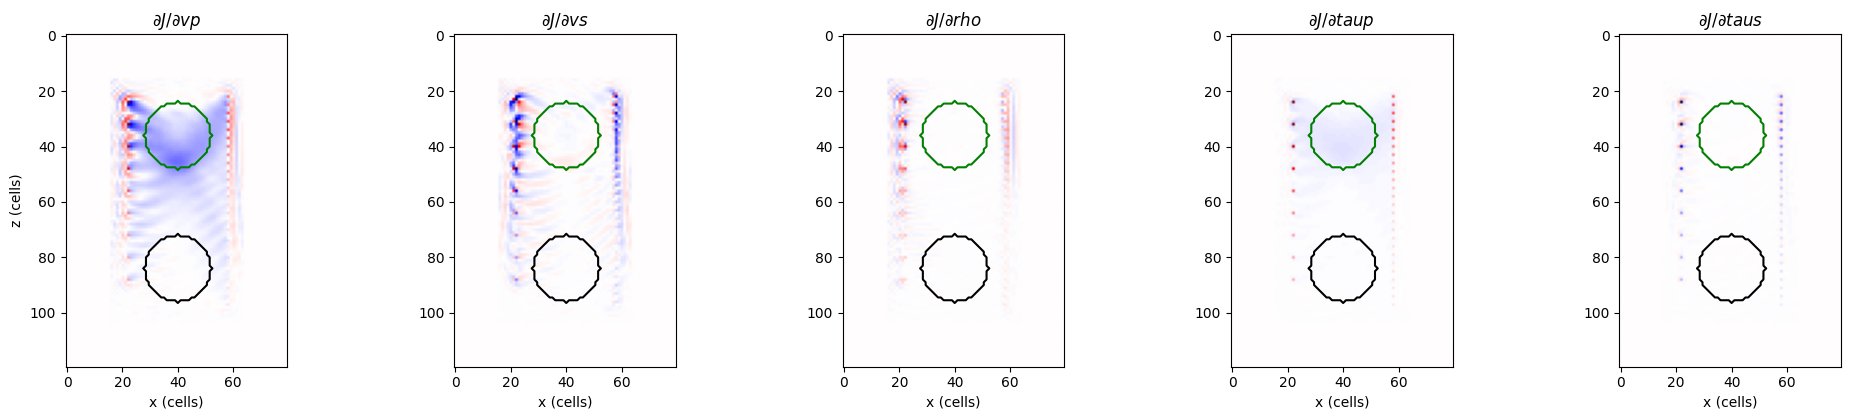

In [13]:
d = np.load("_visco_crosstalk_data.npz")
inA, inB = d["inA"], d["inB"]
names = ["vp", "vs", "rho", "taup", "taus"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4.3))
for ax, n in zip(axes, names):
    g = d["grad_" + n]
    vmax = np.abs(g).max()
    im = ax.imshow(g, cmap="seismic", vmin=-vmax, vmax=vmax)
    ax.contour(inA.astype(float), [0.5], colors="g", linewidths=1.5)
    ax.contour(inB.astype(float), [0.5], colors="k", linewidths=1.5)
    ax.set_title(r"$\partial J/\partial %s$" % n)
    ax.set_xlabel("x (cells)")
axes[0].set_ylabel("z (cells)")
plt.tight_layout()

for n in names:
    g = d["grad_" + n]
    print("%-4s  peak@A(green)=%.3e  peak@B(black)=%.3e"
          % (n, np.abs(g[inA]).max(), np.abs(g[inB]).max()))


Green marks inclusion A (velocity), black marks inclusion B (attenuation).

- **$v_p$** localizes cleanly at A: a single coherent lobe filling the green
  circle, and essentially nothing at B.
- **$v_s$** shows the same pattern, more weakly -- $v_s$ is a harder parameter
  to resolve than $v_p$ in a P-wave-dominated crosswell survey, a well-known
  characteristic of this kind of acquisition rather than something specific to
  this model.
- **$\rho$** is barely visible above the noise floor anywhere -- density is
  routinely the weakest-resolved elastic parameter, consistent with that.
- **$\tau_p$ shows the same lobe as $v_p$, centred on inclusion A rather than
  on its own attenuation anomaly at B.** In this configuration the $\tau_p$
  gradient is dominated by the co-located velocity anomaly rather than by the
  attenuation feature it is meant to be sensitive to.
- **$\tau_s$** is much weaker throughout, with only a faint response at A and
  nothing conclusive at B.

The practical guidance from this: **do not use $\partial J/\partial\tau_p$ or
$\partial J/\partial\tau_s$ quantitatively in a model that also has velocity
structure** -- the crosstalk from a co-located velocity anomaly can dominate
the attenuation gradient entirely. A $\tau$-only inversion (no velocity
anomaly present) is a more reliable use of this gradient today; see
`ViscoelasticCrosswellInversion.ipynb`.


## Where to go next

- [Using Scipy](UsingScipy.ipynb) -- feed this gradient to an off-the-shelf
  optimizer to run an actual FWI loop.
- [Source inversion](source_inversion.ipynb) -- estimate the source wavelet
  rather than the model.
- [Reverse-time migration](../Imaging/ReverseTimeMigration.ipynb) -- the same
  adjoint machinery used for imaging instead of inversion.
- [SeisCL in PyTorch](../DeepLearning/SeisCLinPyTorch.ipynb) -- the same
  gradient exposed through `torch.autograd`, which removes the two-call
  checkpoint bookkeeping entirely and composes with neural networks.
- [Dot-product tests](../Accuracy/DotProductTests.ipynb) -- kernel-level adjoint
  correctness.
